In [16]:
import pandas as pd

df = pd.read_csv("data/salesdaily.csv")
df

,datum,M01AB,M01AE,N02BA,N02BE,N05B,N05C,R03,R06,Year,Month,Hour,Weekday Name
0,1/2/2014,0.00,3.670,3.40,32.40,7.0,0.0,0.0,2.00,2014,1,248,Thursday
1,1/3/2014,8.00,4.000,4.40,50.60,16.0,0.0,20.0,4.00,2014,1,276,Friday
2,1/4/2014,2.00,1.000,6.50,61.85,10.0,0.0,9.0,1.00,2014,1,276,Saturday
3,1/5/2014,4.00,3.000,7.00,41.10,8.0,0.0,3.0,0.00,2014,1,276,Sunday
4,1/6/2014,5.00,1.000,4.50,21.70,16.0,2.0,6.0,2.00,2014,1,276,Monday
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2101,10/4/2019,7.34,5.683,2.25,22.45,13.0,0.0,1.0,1.00,2019,10,276,Friday
2102,10/5/2019,3.84,5.010,6.00,25.40,7.0,0.0,0.0,0.33,2019,10,276,Saturday
2103,10/6/2019,4.00,11.690,2.00,34.60,6.0,0.0,5.0,4.20,2019,10,276,Sunday
2104,10/7/2019,7.34,4.507,3.00,50.80,6.0,0.0,10.0,1.00,2019,10,276,Monday


In [11]:
#What are the total sales quantities for each drug category (ATC code)?
firstQuery = df.iloc[:, 1:9].sum()
firstQuery

M01AB    10600.937083
M01AE     8204.618646
N02BA     8172.209000
N02BE    63005.402708
N05B     18645.737500
N05C      1249.958333
R03      11608.822917
R06       6107.817500
dtype: float64

<AxesSubplot: >

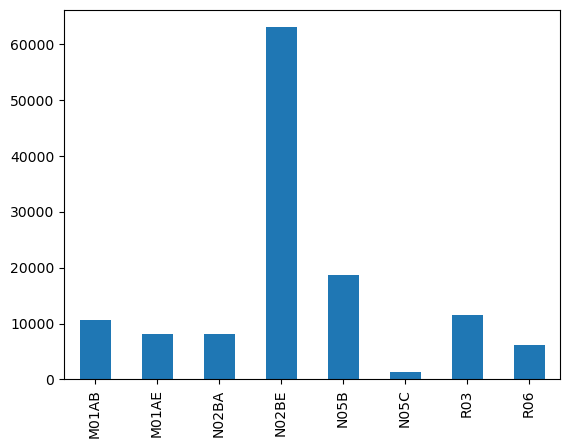

In [12]:
firstQuery.plot.bar()

In [13]:
#Which individual drug brands have the highest total sales?
df.iloc[:, 1:9].sum().idxmax()

'N02BE'

In [44]:
#Check dtypes for next question
df.dtypes

datum           datetime64[ns]
M01AB                  float64
M01AE                  float64
N02BA                  float64
N02BE                  float64
N05B                   float64
N05C                   float64
R03                    float64
R06                    float64
Year                     int64
Month                   object
Hour                     int64
Weekday Name            object
dtype: object

In [20]:
#Change dtype of 'datum' column from object to datetime
df['datum'] = pd.to_datetime(df['datum'])

In [22]:
#Which three drugs have the highest sales in January 2015
maskA = (df['datum'] >= '1/1/2015') & (df['datum'] <= '1-31-2015')
df.loc[maskA].iloc[:, 1:9].sum().nlargest(3)

N02BE    1044.24
N05B      463.00
R03       177.25
dtype: float64

<AxesSubplot: >

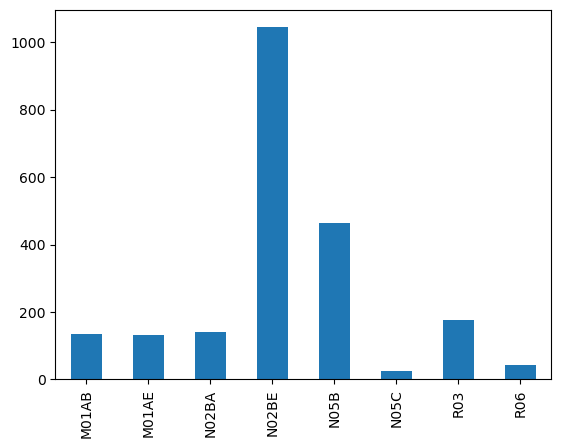

In [23]:
df.loc[maskA].iloc[:, 1:9].sum().plot.bar()

In [24]:
#Which three drugs have the highest sales in July 2016
maskB = (df['datum'] >= '7/1/2015') & (df['datum'] <= '7-31-2015')
df.loc[maskB].iloc[:, 1:9].sum().nlargest(3)

N02BE    708.828
N05B     203.000
M01AB    175.610
dtype: float64

<AxesSubplot: >

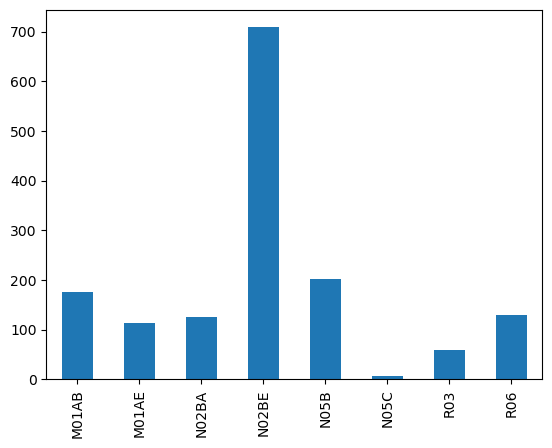

In [25]:
df.loc[maskB].iloc[:, 1:9].sum().plot.bar()

In [26]:
#Which three drugs have the highest sales in September 2017
maskC = (df['datum'] >= '9/1/2015') & (df['datum'] <= '9-30-2015')
df.loc[maskC].iloc[:, 1:9].sum().nlargest(3)

N02BE    852.125
N05B     243.500
M01AB    166.220
dtype: float64

<AxesSubplot: >

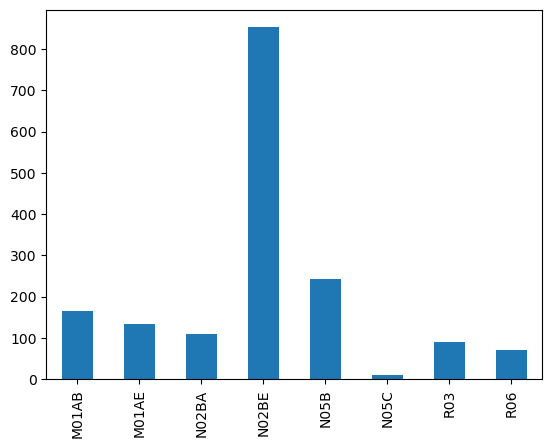

In [27]:
df.loc[maskC].iloc[:, 1:9].sum().plot.bar()

In [28]:
#Which drug has sold the most often in 2017?
maskD = (df['datum'] >= '1/1/2017') & (df['datum'] <= '12-31-2017')
df.loc[maskD].iloc[:, 1:9].sum().idxmax()

'N02BE'

<AxesSubplot: >

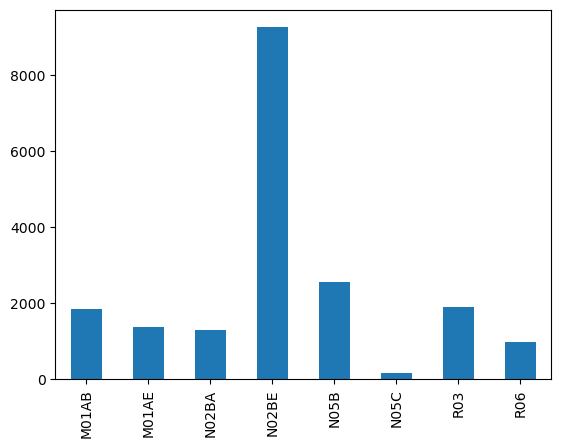

In [29]:
df.loc[maskD].iloc[:, 1:9].sum().plot.bar()

In [30]:
#Which drug category has the highest average daily sales?
df.iloc[:, 1:9].mean().idxmax()

'N02BE'

<AxesSubplot: >

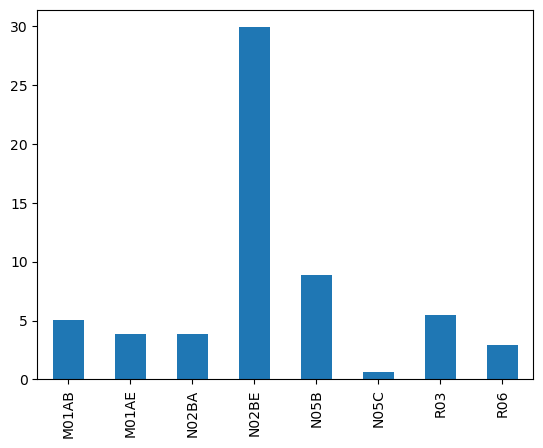

In [11]:
df.iloc[:, 1:9].mean().plot.bar()

In [59]:
#Respiratory drugs (R03) sells by month and year, the two last months of 2019 are missing.
gb = df.iloc[:, [0, 7]].resample(rule='M', on='datum').sum()
gb

,R03
datum,
2014-01-31,112.000000
2014-02-28,122.000000
2014-03-31,112.000000
2014-04-30,97.000000
2014-05-31,107.000000
...,...
2019-06-30,142.000000
2019-07-31,115.000000
2019-08-31,145.000000


In [60]:
#Are respiratory drugs (R03) sold more during specific months?
gb = df.iloc[:, 7].groupby([df.datum.dt.month, df.datum.dt.year]).sum().unstack()
gb

datum,2014,2015,2016,2017,2018,2019
datum,,,,,,
1,112.0,177.25,174.0,196.406250,219.00,386.000000
2,122.0,208.00,245.0,140.333333,224.25,226.000000
3,112.0,170.00,253.0,109.000000,269.00,257.000000
4,97.0,97.00,216.0,180.875000,229.00,219.000000
5,107.0,100.00,131.0,128.000000,167.00,298.291667
6,57.0,193.00,127.0,163.000000,101.00,142.000000
7,61.0,60.00,109.0,115.000000,90.00,115.000000
8,37.0,45.00,116.0,75.000000,159.00,145.000000
9,115.0,91.00,121.0,139.000000,205.00,121.416667


<AxesSubplot: xlabel='datum'>

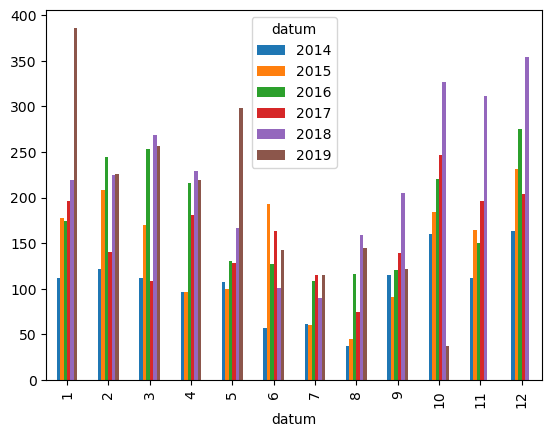

In [61]:
gb.plot.bar()